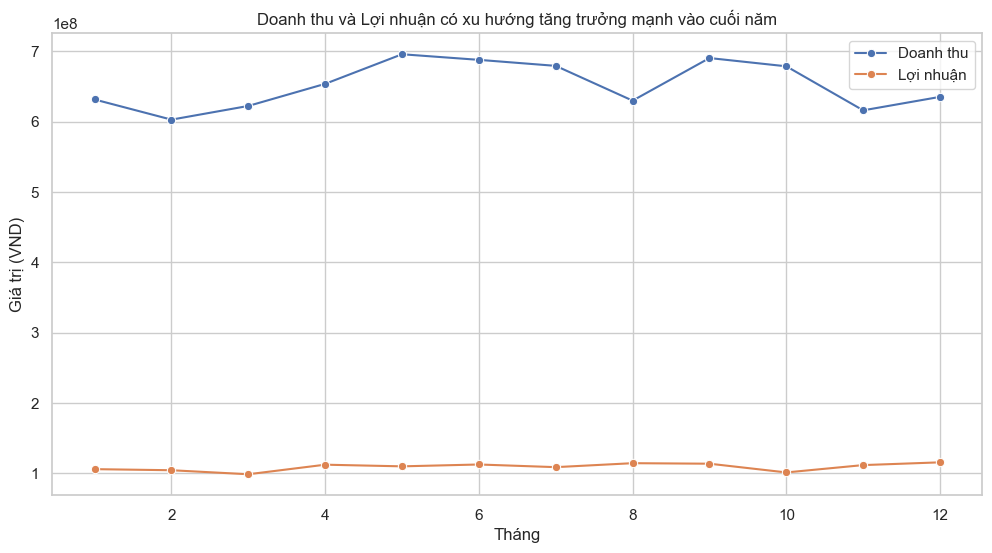

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\2625924097.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_stats.sort_values('profit_margin', ascending=False),


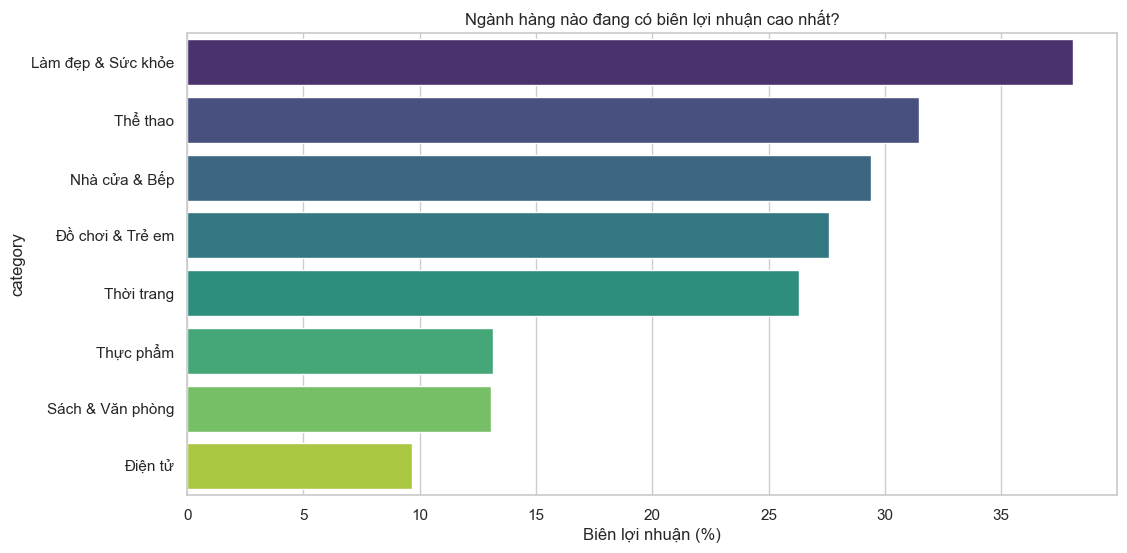

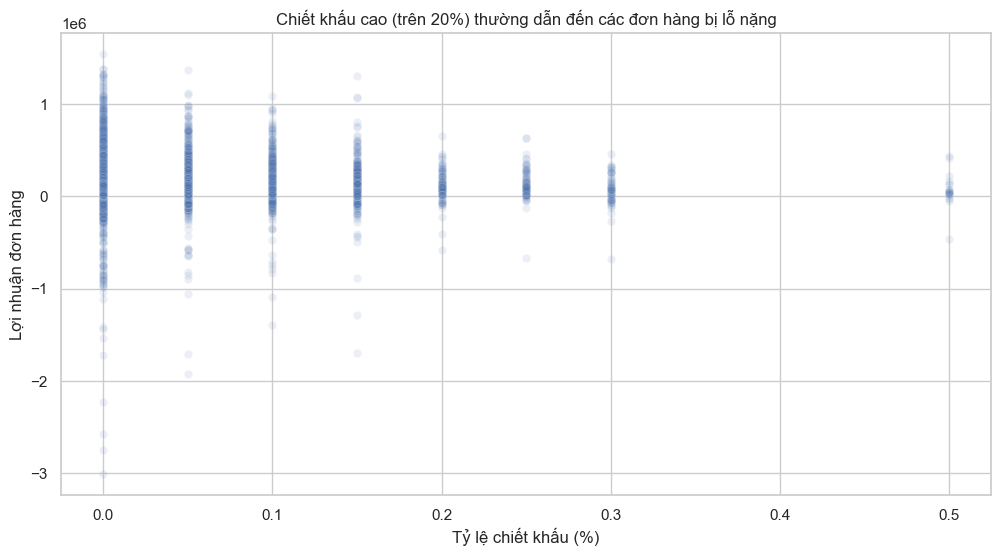

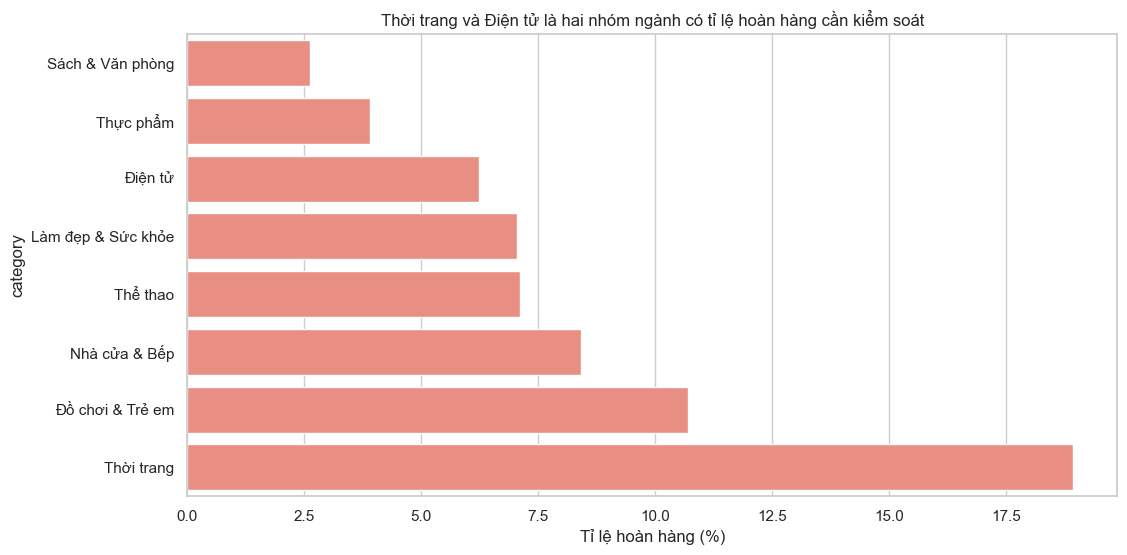

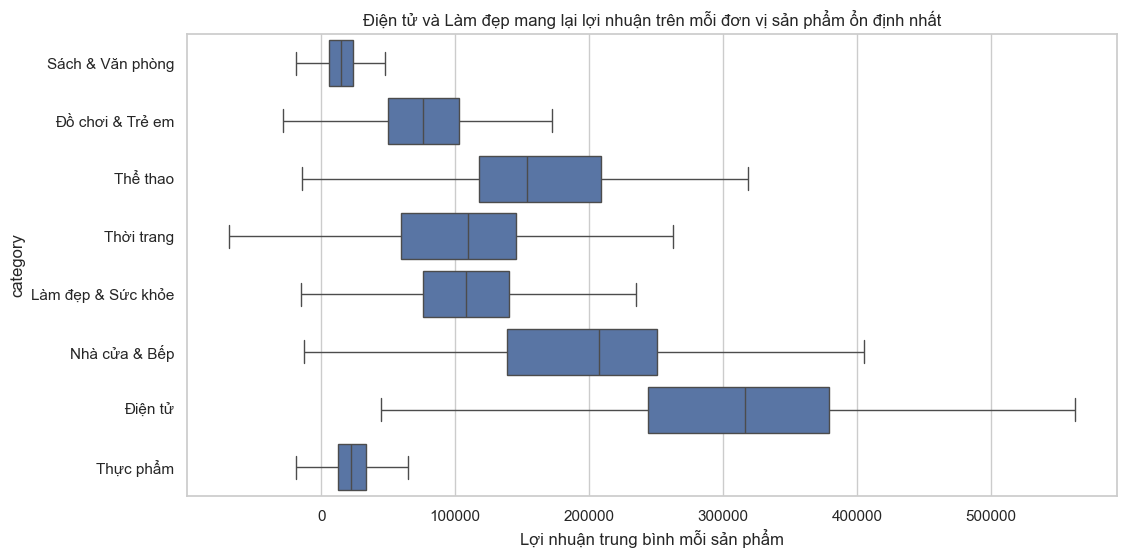

Phân tích hoàn tất. Dữ liệu sẵn sàng để đưa vào Story Deck 5 slides.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
file_path = r'D:\DOWNLOAD2026--\vietnam_ecommerce_2023.csv'
df = pd.read_csv(file_path, sep=None, engine='python')

# Thiết lập phong cách ch biểu đồ
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- BIỂU ĐỒ 1: TỔNG QUAN DOANH THU & LỢI NHUẬN THEO THÁNG ---
# Mục tiêu: Cho thấy xu hướng tăng trưởng trong năm 2023
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_data = df.groupby('month').agg({'net_value': 'sum', 'profit': 'sum'}).reset_index()

plt.figure()
sns.lineplot(data=monthly_data, x='month', y='net_value', marker='o', label='Doanh thu')
sns.lineplot(data=monthly_data, x='month', y='profit', marker='o', label='Lợi nhuận')
plt.title('Doanh thu và Lợi nhuận có xu hướng tăng trưởng mạnh vào cuối năm')
plt.xlabel('Tháng')
plt.ylabel('Giá trị (VND)')
plt.legend()
plt.show()

# --- BIỂU ĐỒ 2: REVENUE VS PROFIT MARGIN THEO NGÀNH (S2) ---
# Mục tiêu: Xác định ngành hàng nào đóng góp lợi nhuận thực tế tốt nhất
category_stats = df.groupby('category').agg({'net_value': 'sum', 'profit': 'sum'}).reset_index()
category_stats['profit_margin'] = (category_stats['profit'] / category_stats['net_value']) * 100

plt.figure()
sns.barplot(data=category_stats.sort_values('profit_margin', ascending=False), 
            x='profit_margin', y='category', palette='viridis')
plt.title('Ngành hàng nào đang có biên lợi nhuận cao nhất?')
plt.xlabel('Biên lợi nhuận (%)')
plt.show()

# --- BIỂU ĐỒ 3: TÁC ĐỘNG CỦA CHIẾT KHẤU ĐẾN LỢI NHUẬN (S3) ---
# Mục tiêu: Kiểm tra xem việc giảm giá quá đà có làm mất tiền không
plt.figure()
sns.scatterplot(data=df, x='discount_pct', y='profit', alpha=0.1)
plt.title('Chiết khấu cao (trên 20%) thường dẫn đến các đơn hàng bị lỗ nặng')
plt.xlabel('Tỷ lệ chiết khấu (%)')
plt.ylabel('Lợi nhuận đơn hàng')
plt.show()

# --- BIỂU ĐỒ 4: TỈ LỆ HOÀN HÀNG THEO NGÀNH (S5) ---
# Mục tiêu: Tìm ra "điểm đau" khiến công ty mất tiền vận hành
return_rate = df.groupby('category')['returned'].mean().reset_index()
return_rate['returned'] = return_rate['returned'] * 100

plt.figure()
sns.barplot(data=return_rate.sort_values('returned'), x='returned', y='category', color='salmon')
plt.title('Thời trang và Điện tử là hai nhóm ngành có tỉ lệ hoàn hàng cần kiểm soát')
plt.xlabel('Tỉ lệ hoàn hàng (%)')
plt.show()

# --- BIỂU ĐỒ 5: TOP NGÀNH HÀNG THEO LỢI NHUẬN TRÊN MỖI ĐƠN HÀNG ---
# Mục tiêu: Khuyến nghị ngành hàng ưu tiên đầu tư năm 2024
df['profit_per_order'] = df['profit'] / df['quantity']
top_profit_per_unit = df.groupby('category')['profit_per_order'].mean().reset_index()

plt.figure()
sns.boxplot(data=df, x='profit_per_order', y='category', showfliers=False)
plt.title('Điện tử và Làm đẹp mang lại lợi nhuận trên mỗi đơn vị sản phẩm ổn định nhất')
plt.xlabel('Lợi nhuận trung bình mỗi sản phẩm')
plt.show()

print("Phân tích hoàn tất. Dữ liệu sẵn sàng để đưa vào Story Deck 5 slides.")